# 🚀 Fase 4: Engenharia de Sinais Avançada
**Decomposição Sazonal e Transformada Wavelet Discreta (DWT)**

Nesta fase, testaremos técnicas da física e engenharia de sinais para extrair padrões do nosso dataset multivariado (Beijing PM2.5).

Técnicas:
1. **Decomposição Sazonal:** Separar a série temporal em Tendência (Trend) e Sazonalidade.
2. **Transformada Wavelet Discreta (DWT):** Analisar frequências em janelas móveis de 7 dias, extraindo coeficientes de Aproximação (Macrotendência) e Detalhe (Ruído Rápido).

Compararemos:
1. Apenas Decomposição Sazonal
2. Apenas Transformada Wavelet
3. **Híbrido Total (Manual FE + Decomposição + Wavelets)**


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time
import warnings
warnings.filterwarnings('ignore')

from statsmodels.tsa.seasonal import seasonal_decompose
import pywt
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

plt.style.use('dark_background')



## 1. Carregamento e Preparação do Dataset


In [2]:
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00381/PRSA_data_2010.1.1-2014.12.31.csv"
df_raw = pd.read_csv(url)

# Formatação
df_raw['date'] = pd.to_datetime(df_raw[['year', 'month', 'day', 'hour']])
cols_of_interest = ['pm2.5', 'DEWP', 'TEMP', 'PRES', 'Iws']
df_raw = df_raw[['date'] + cols_of_interest].copy()
df_raw['pm2.5'] = df_raw['pm2.5'].interpolate(method='linear')
df_raw = df_raw.dropna()

# Agregação Diária
df_daily = df_raw.set_index('date').resample('D').mean().reset_index()
print(f"Total de dias: {len(df_daily)}")

# Criação do Target (pm2.5 do dia seguinte)
df_daily['target'] = df_daily['pm2.5'].shift(-1)

# Recriar as features manuais para o Híbrido
df_manual = df_daily.copy()
lags = [1, 2, 3, 7]
for col in cols_of_interest:
    for lag in lags:
        df_manual[f'{col}_lag_{lag}'] = df_manual[col].shift(lag)
    df_manual[f'{col}_rolling_mean_7'] = df_manual[col].rolling(window=7).mean()
df_manual['month'] = df_manual['date'].dt.month
df_manual['day_of_week'] = df_manual['date'].dt.dayofweek



Total de dias: 1825


## 2. Decomposição Sazonal (Prevenindo Data Leakage)
A decomposição clássica calcula uma média móvel centralizada, o que espiona o futuro. Para usá-la como Feature preditiva de forma justa, devemos *shiftar* os resultados no tempo (shift = período/2 + 1).


In [3]:
start_time = time.time()
df_decomp = pd.DataFrame(index=df_daily.index)

period = 7 # Sazonalidade Semanal
safe_shift = (period // 2) + 1 # Impede que o modelo veja o futuro

for col in cols_of_interest:
    # Extrapolate trend preenche as bordas para não perder tantos dados
    decomp = seasonal_decompose(df_daily[col].fillna(method='bfill'), model='additive', period=period, extrapolate_trend='freq')
    
    # Aplicando o shift de segurança para usá-las como features
    df_decomp[f'{col}_trend'] = decomp.trend.shift(safe_shift)
    df_decomp[f'{col}_seasonal'] = decomp.seasonal.shift(safe_shift)
    df_decomp[f'{col}_resid'] = decomp.resid.shift(safe_shift)

decomp_time = time.time() - start_time
print(f"Decomposição Sazonal concluída em {decomp_time:.2f}s")
print(f"Shape Decomposição: {df_decomp.shape}")



Decomposição Sazonal concluída em 0.01s
Shape Decomposição: (1825, 15)


## 3. Transformada Wavelet Discreta (DWT) em Janelas Móveis
Para cada dia $t$, olharemos uma janela de 7 dias $[t-6, t]$ e extrairemos a Wavelet. Isso é extremamente poderoso e 100% seguro contra vazamento de dados.


In [4]:
start_time = time.time()
window_size = 7
wavelet_name = 'db2' # Família Daubechies

wavelet_features = []

for i in range(len(df_daily)):
    if i < window_size - 1:
        # Sem dados suficientes para a janela, preenche com Nans
        row_features = {f'{col}_dwt_cA_mean': np.nan for col in cols_of_interest}
    else:
        row_features = {}
        for col in cols_of_interest:
            # Pega a janela de 7 dias terminando no dia atual i
            window = df_daily[col].iloc[i - window_size + 1 : i + 1].values
            
            # Calcula a Wavelet
            cA, cD = pywt.dwt(window, wavelet_name)
            
            # Como a wavelet retorna arrays, vamos usar a média e desvio dos coeficientes 
            # de Aproximação (cA) e Detalhe (cD) para resumir a onda
            row_features[f'{col}_dwt_cA_mean'] = np.mean(cA)
            row_features[f'{col}_dwt_cA_std'] = np.std(cA)
            row_features[f'{col}_dwt_cD_mean'] = np.mean(cD)
            row_features[f'{col}_dwt_cD_std'] = np.std(cD)
            
    wavelet_features.append(row_features)

df_wavelet = pd.DataFrame(wavelet_features, index=df_daily.index)
wavelet_time = time.time() - start_time
print(f"Transformada Wavelet concluída em {wavelet_time:.2f}s")
print(f"Shape Wavelet: {df_wavelet.shape}")



Transformada Wavelet concluída em 0.42s
Shape Wavelet: (1825, 20)


## 4. O Duelo de Sinais (Random Forest)


Amostras finais viáveis (após drops de janelas e shifts): 1817
Treinando Florestas...


[1. Apenas Manual FE (Baseline)] MAE: 57.8834 | Tempo Treino: 0.54s


[2. Apenas Decomposição Sazonal] MAE: 60.8288 | Tempo Treino: 0.31s


[3. Apenas Wavelets (DWT)] MAE: 57.2330 | Tempo Treino: 0.47s


[4. Híbrido Total (Manual + Decomp + Wavelets)] MAE: 54.1941 | Tempo Treino: 1.19s


,Cenário,N_Features,MAE,RMSE,Train_Time(s)
3,4. Híbrido Total (Manual + Decomp + Wavelets),62,54.194066,73.735018,1.191214
2,3. Apenas Wavelets (DWT),20,57.233009,77.066216,0.472188
0,1. Apenas Manual FE (Baseline),27,57.883382,78.073064,0.542255
1,2. Apenas Decomposição Sazonal,15,60.828751,81.515637,0.313686


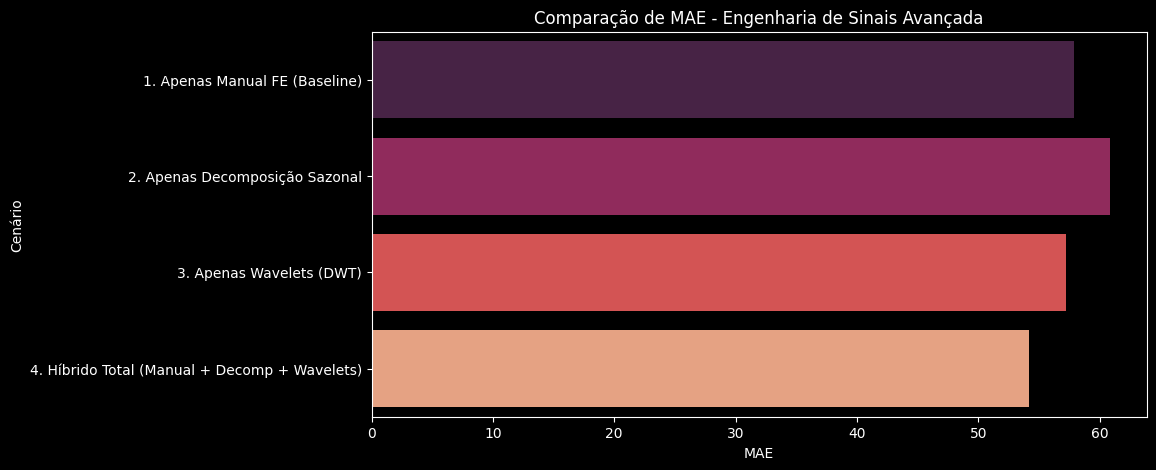

In [5]:
# Vamos juntar tudo e dropar NaNs globais para garantir que os testes rodem na mesma base exata
df_full = df_manual.copy()
df_full = pd.concat([df_full, df_decomp, df_wavelet], axis=1)
df_full = df_full.dropna()

print(f"Amostras finais viáveis (após drops de janelas e shifts): {df_full.shape[0]}")

y = df_full['target']
cols_to_drop = ['date', 'target'] + cols_of_interest

X_manual = df_full.drop(columns=cols_to_drop)[df_manual.drop(columns=cols_to_drop).columns]
X_decomp = df_full[df_decomp.columns]
X_wavelet = df_full[df_wavelet.columns]
X_hybrid = df_full.drop(columns=cols_to_drop)

# Testes
test_size = 365
results = []

def evaluate_rf(X, name):
    X_train = X.iloc[:-test_size]
    y_train = y.iloc[:-test_size]
    X_test = X.iloc[-test_size:]
    y_test = y.iloc[-test_size:]
    
    rf = RandomForestRegressor(random_state=42, n_estimators=100, n_jobs=-1)
    
    start = time.time()
    rf.fit(X_train, y_train)
    t_time = time.time() - start
    
    preds = rf.predict(X_test)
    mae = mean_absolute_error(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    
    results.append({
        'Cenário': name,
        'N_Features': X_train.shape[1],
        'MAE': mae,
        'RMSE': rmse,
        'Train_Time(s)': t_time
    })
    print(f"[{name}] MAE: {mae:.4f} | Tempo Treino: {t_time:.2f}s")

print("Treinando Florestas...")
evaluate_rf(X_manual, '1. Apenas Manual FE (Baseline)')
evaluate_rf(X_decomp, '2. Apenas Decomposição Sazonal')
evaluate_rf(X_wavelet, '3. Apenas Wavelets (DWT)')
evaluate_rf(X_hybrid, '4. Híbrido Total (Manual + Decomp + Wavelets)')

res_df = pd.DataFrame(results)
display(res_df.sort_values('MAE'))

plt.figure(figsize=(10,5))
sns.barplot(data=res_df, x='MAE', y='Cenário', palette='rocket')
plt.title('Comparação de MAE - Engenharia de Sinais Avançada')
plt.show()

